In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("iris_data")

In [4]:
import os

print(os.listdir("iris_data"))

['Iris.csv']


In [5]:
df = pd.read_csv("iris_data/Iris.csv")

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [7]:
print(df.isnull().sum())

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [8]:
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [10]:
model = KNeighborsClassifier()
model.fit(X_train, y_train)

KNeighborsClassifier()

In [11]:
model = KNeighborsClassifier()
model.fit(X_train, y_train)

KNeighborsClassifier()

In [12]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 1.0
Accuracy (%): 100.0


In [13]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [14]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


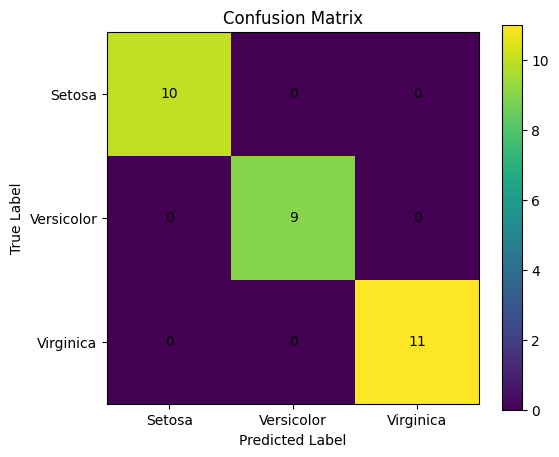

In [15]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1, 2], ["Setosa", "Versicolor", "Virginica"])
plt.yticks([0, 1, 2], ["Setosa", "Versicolor", "Virginica"])

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [16]:
sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
)

prediction = model.predict(sample)

print("Predicted Species:", prediction[0])

Predicted Species: Iris-setosa


In [17]:
print("Number of samples in each species:")
print(df['Species'].value_counts())

Number of samples in each species:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [18]:
print("Basic Statistics:")
print(df.describe())

Basic Statistics:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


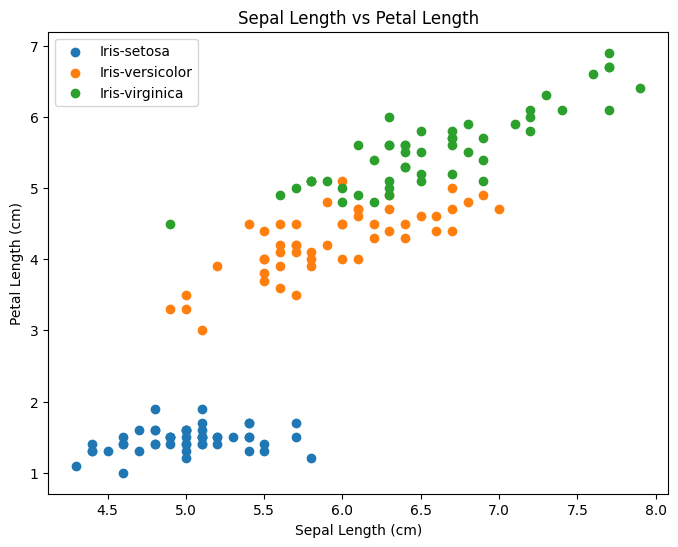

In [19]:
plt.figure(figsize=(8, 6))

for species in df['Species'].unique():
    data = df[df['Species'] == species]
    plt.scatter(
        data['SepalLengthCm'],
        data['PetalLengthCm'],
        label=species
    )

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Sepal Length vs Petal Length")
plt.legend()
plt.show()

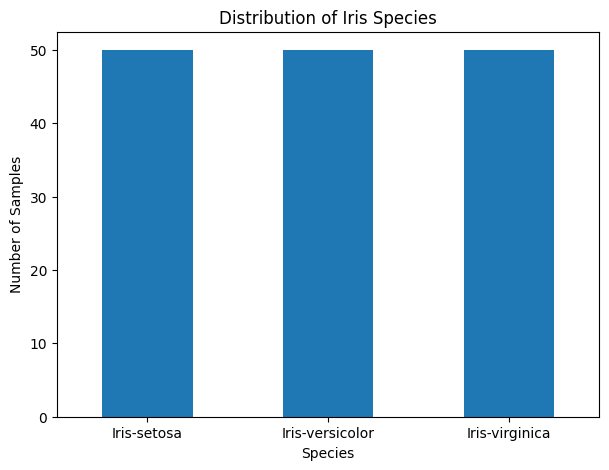

In [20]:
plt.figure(figsize=(7, 5))

df['Species'].value_counts().plot(kind='bar')

plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.title("Distribution of Iris Species")
plt.xticks(rotation=0)
plt.show()

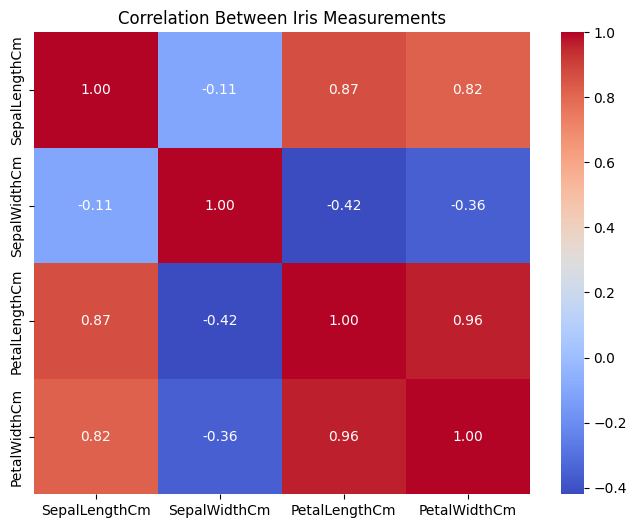

In [21]:
import seaborn as sns

plt.figure(figsize=(8, 6))

correlation = df[
    ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Between Iris Measurements")
plt.show()

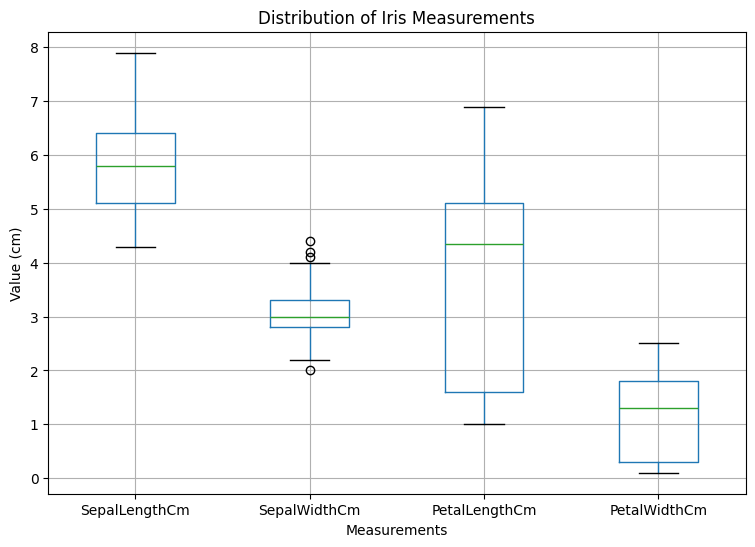

In [22]:
plt.figure(figsize=(9, 6))

df[
    ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
].boxplot()

plt.title("Distribution of Iris Measurements")
plt.xlabel("Measurements")
plt.ylabel("Value (cm)")
plt.xticks(rotation=0)
plt.show()

In [23]:
import joblib

joblib.dump(model, "iris_knn_model.pkl")

print("Model saved successfully as iris_knn_model.pkl")

Model saved successfully as iris_knn_model.pkl


In [24]:
print("===== IRIS FLOWER CLASSIFICATION RESULTS =====")
print("Model: K-Nearest Neighbors (KNN)")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

===== IRIS FLOWER CLASSIFICATION RESULTS =====
Model: K-Nearest Neighbors (KNN)
Training samples: 120
Testing samples: 30
Accuracy: 1.0
Accuracy (%): 100.0


Iris Flower Classification

Project Overview

This project focuses on classifying Iris flowers into three species:
Iris-setosa, Iris-versicolor, and Iris-virginica.

The classification is performed using the K-Nearest Neighbors (KNN)
machine learning algorithm based on four flower measurements:
Sepal Length, Sepal Width, Petal Length, and Petal Width.

The model is trained using 80% of the dataset and evaluated using
the remaining 20% of the data.

Dataset

The Iris dataset contains 150 flower samples belonging to three species:
Iris-setosa, Iris-versicolor, and Iris-virginica.

The dataset contains four measurement features:
- Sepal Length (cm)
- Sepal Width (cm)
- Petal Length (cm)
- Petal Width (cm)

There are 50 samples for each species, and there are no missing values
in the dataset.

 Data Exploration

The dataset was loaded using Pandas and examined to understand its
structure and contents.

The dataset contains 150 rows and 6 columns, including the Id column,
four flower measurement columns, and the Species column.

The dataset was checked for missing values, and no missing values were
found.

Model Building

The K-Nearest Neighbors (KNN) algorithm was used for classification.

The dataset was divided into training and testing sets using an 80:20
split. Therefore, 120 samples were used for training and 30 samples
were used for testing.

The KNN model was trained using the four flower measurement features
and the Species column was used as the target variable.

Model Evaluation

The trained KNN model was evaluated using the test dataset.

The model achieved an accuracy of 100% on the 30 testing samples.

The classification report showed precision, recall, and F1-score of 1.00
for Iris-setosa, Iris-versicolor, and Iris-virginica.

The confusion matrix also showed that all 30 test samples were correctly
classified.

Visualizations

Several visualizations were created to better understand the Iris dataset:

1. Sepal Length vs Petal Length scatter plot
2. Iris Species Distribution bar chart
3. Correlation Heatmap of the flower measurements
4. Distribution of Iris Measurements using box plots
5. Confusion Matrix showing the model's predictions

These visualizations help explain the characteristics of the dataset and
the performance of the classification model.

Conclusion

The Iris Flower Classification model successfully classified Iris flowers
into three species using the K-Nearest Neighbors (KNN) algorithm.

The model achieved 100% accuracy on the test dataset of 30 samples.
The visualizations and evaluation metrics helped demonstrate the
performance of the classification model.

The trained model was also saved as `iris_knn_model.pkl`.